## 5 - Histograms & Distributions

### What is a Histogram?
A **histogram** groups numeric values into **bins** (ranges) and shows how many values fall in each bin. It answers: **how are my values distributed?**

> A histogram looks like a bar chart but is fundamentally different - it shows the **distribution of one continuous variable**, not comparisons between categories.

### When to use
✅ Understanding the shape of data (normal, skewed, bimodal?)
✅ Finding outliers
✅ Checking if data is roughly balanced
✅ Comparing two groups' distributions

### Key `plt.hist()` parameters
| Parameter | What it does |
|-----------|-------------|
| `x` | The data |
| `bins` | Number of bins (or `'auto'`) |
| `color` | Bar fill colour |
| `edgecolor` | Border between bars |
| `alpha` | Transparency (useful for overlapping) |
| `density` | Normalise to probability (area = 1) |
| `cumulative` | Cumulative frequency |

### Box plot - `plt.boxplot()`
Shows **5 key statistics** in one compact chart:
```
   ○          ← outlier (beyond 1.5 × IQR)
   ├──────    ← whisker top  (Q3 + 1.5 × IQR)
   ┌──────┐
   │  Q3  │   ← 75th percentile
   │──────│   ← Median (red line)
   │  Q1  │   ← 25th percentile
   └──────┘
   ├──────    ← whisker bottom (Q1 − 1.5 × IQR)
   ○          ← outlier
```

### Violin plot - `plt.violinplot()`
Shows the **full shape of the distribution** - like a mirrored KDE curve — giving more information than a box plot.


In [3]:
import matplotlib.pyplot as plt

### Creating Datasets

In [4]:
import numpy as np

rng     = np.random.default_rng(0)
maths   = rng.normal(65, 15, 200).clip(0, 100)
science = rng.normal(68, 13, 200).clip(0, 100)
english = rng.normal(72, 12, 200).clip(0, 100)
compSci = rng.normal(70, 14, 200).clip(0, 100)

### Plot 1 : Basic histogram

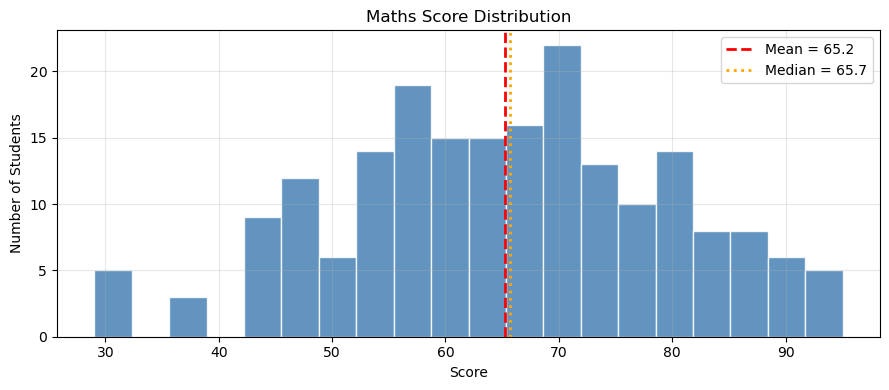

In [6]:
plt.figure(figsize=(9, 4))
plt.hist(maths, bins=20, color='steelblue', edgecolor='white', alpha=0.85)

plt.axvline(maths.mean(),       color='red',    lw=2, ls='--', label=f'Mean = {maths.mean():.1f}')
plt.axvline(np.median(maths),   color='orange', lw=2, ls=':',  label=f'Median = {np.median(maths):.1f}')

plt.title('Maths Score Distribution')
plt.xlabel('Score')
plt.ylabel('Number of Students')

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Plot 2 : Overlapping histograms

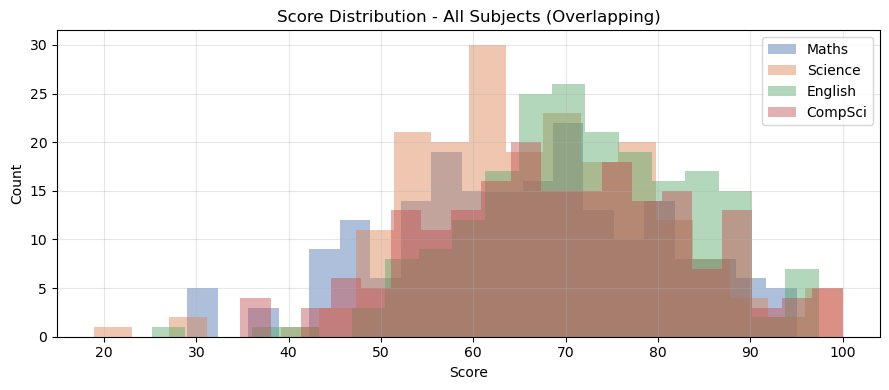

In [7]:
all_data = [maths, science, english, compSci]
labels   = ['Maths', 'Science', 'English', 'CompSci']
colors   = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

plt.figure(figsize=(9, 4))
for data, lbl, col in zip(all_data, labels, colors):
    plt.hist(data, bins=20, alpha=0.45, color=col, label=lbl, edgecolor='none')

plt.title('Score Distribution - All Subjects (Overlapping)')
plt.xlabel('Score')
plt.ylabel('Count')

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Plot 3 : Box plot

C:\Users\Purvi jain\AppData\Local\Temp\ipykernel_22784\1287236449.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(all_data, labels=labels, patch_artist=True, medianprops=dict(color='red', lw=2.5))


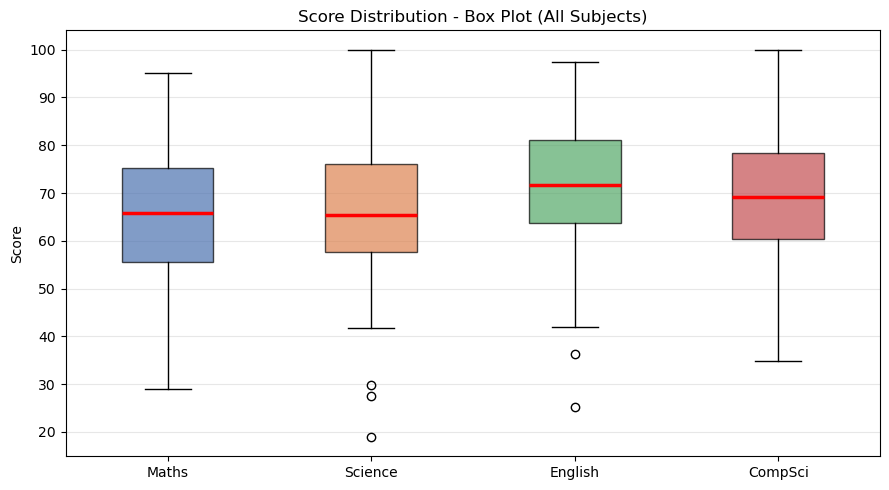

In [8]:
plt.figure(figsize=(9, 5))
bp = plt.boxplot(all_data, labels=labels, patch_artist=True, medianprops=dict(color='red', lw=2.5))

for patch, col in zip(bp['boxes'], colors):
    patch.set_facecolor(col)
    patch.set_alpha(0.7)

plt.title('Score Distribution - Box Plot (All Subjects)')
plt.ylabel('Score')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Plot 4 : Violin plot

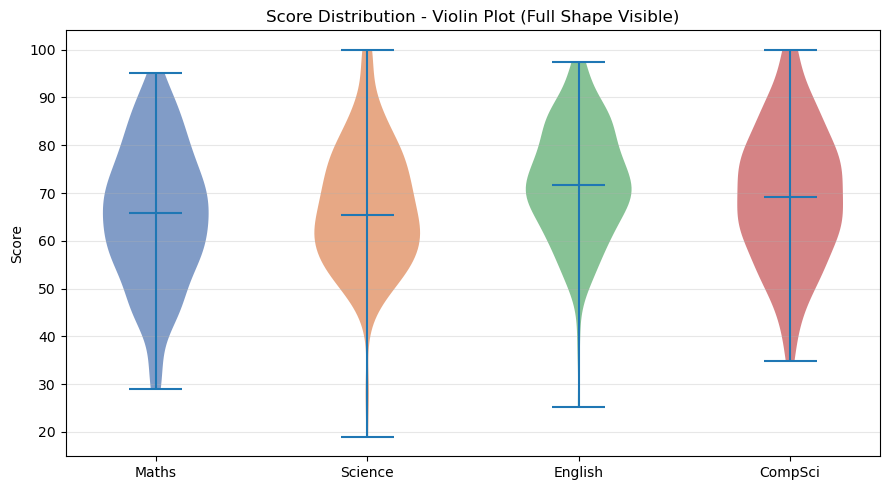

In [9]:
plt.figure(figsize=(9, 5))
vp = plt.violinplot(all_data, positions=[1, 2, 3, 4], showmedians=True)

for body, col in zip(vp['bodies'], colors):
    body.set_facecolor(col)
    body.set_alpha(0.7)

plt.xticks([1, 2, 3, 4], labels)
plt.title('Score Distribution - Violin Plot (Full Shape Visible)')
plt.ylabel('Score')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()